<a href="https://colab.research.google.com/github/Sythaz/tomalyze/blob/main/Collab/PCVK_Gabungan_Seg_Enh_Ekst_Manhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Segmentasi**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



========== RIPE ==========
[SAVED] 25/100
[SAVED] 50/100
[SAVED] 75/100
[SAVED] 100/100

=== VISUALISASI 3 GAMBAR RIPE ===


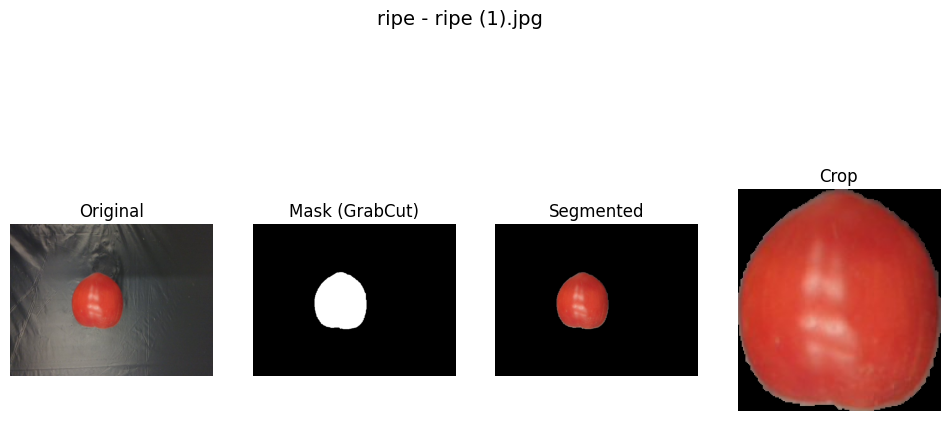

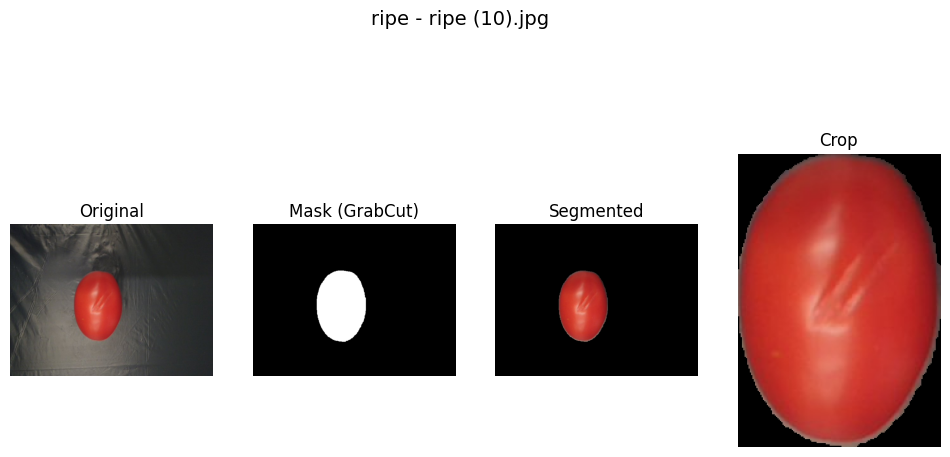

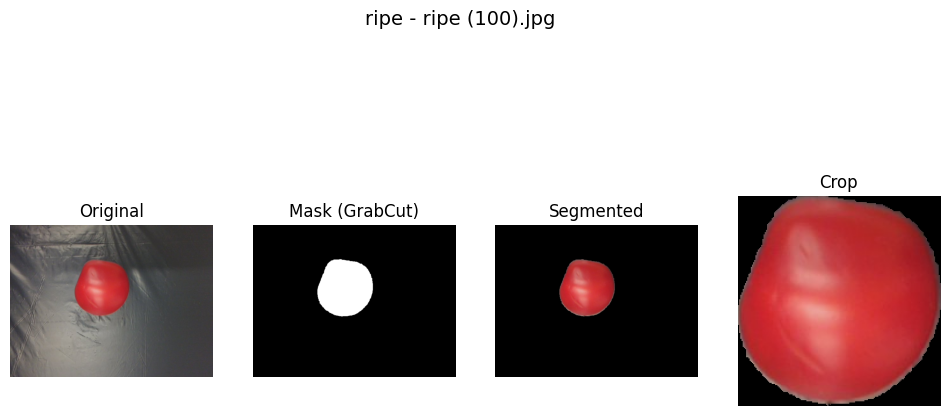


========== HALF-RIPE ==========
[SAVED] 25/100
[SAVED] 50/100
[SAVED] 75/100
[SAVED] 100/100

=== VISUALISASI 3 GAMBAR HALF-RIPE ===


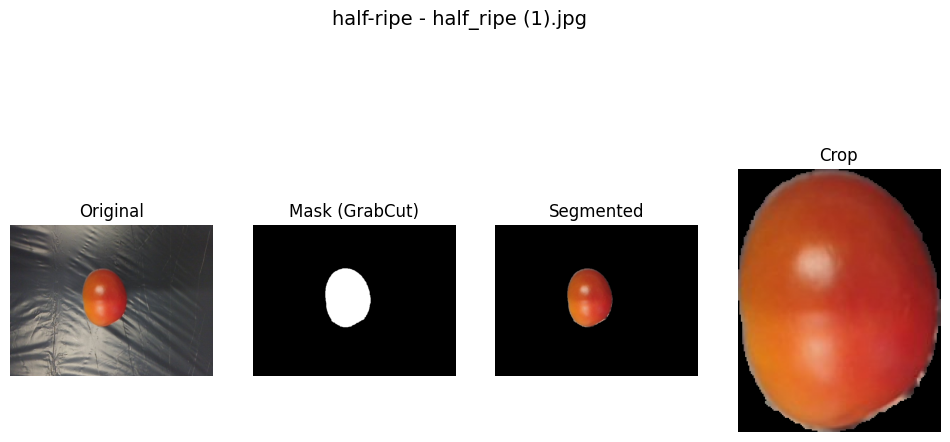

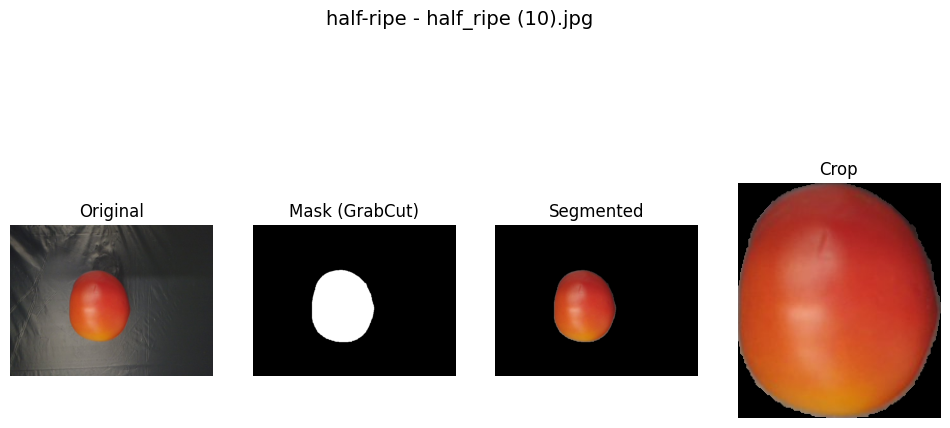

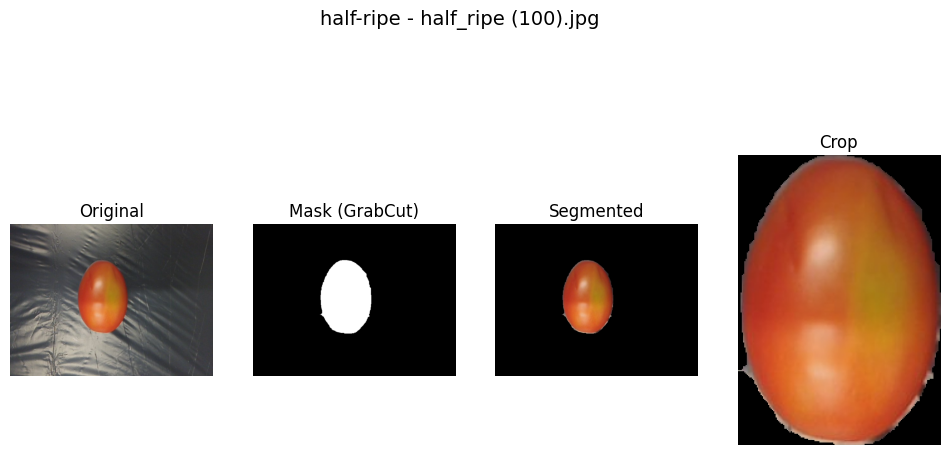


========== UNRIPE ==========
[SAVED] 25/100
[SAVED] 50/100
[SAVED] 75/100
[SAVED] 100/100

=== VISUALISASI 3 GAMBAR UNRIPE ===


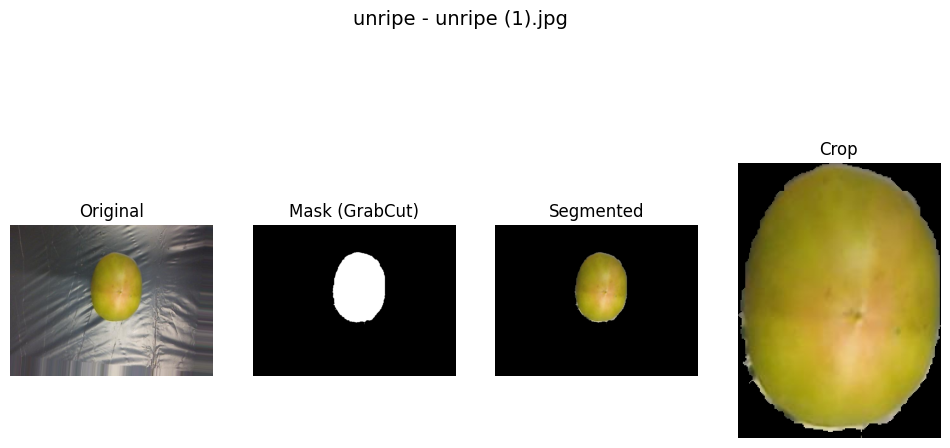

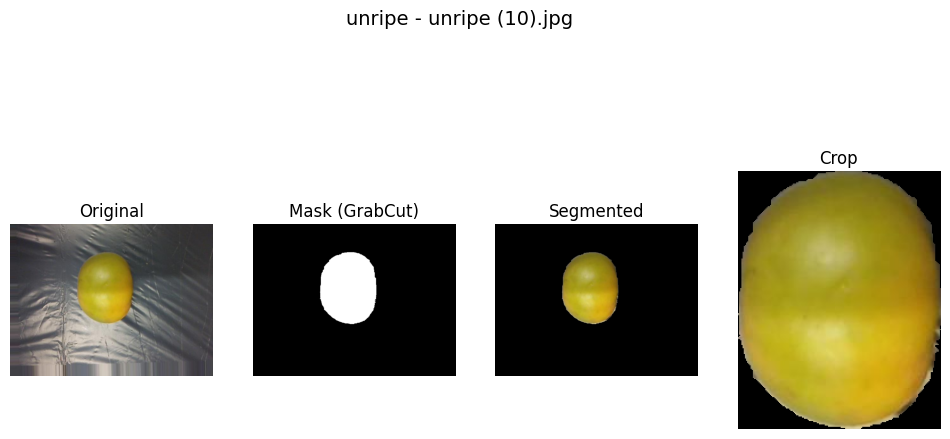

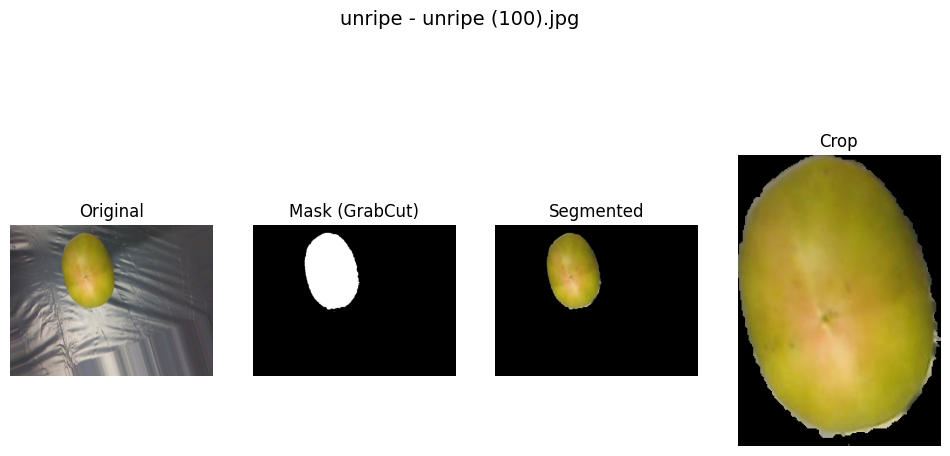

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def auto_segment_grabcut(img_bgr):

    # --- A. INITIAL BOUNDING BOX ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 40, 50])
    upper = np.array([180, 255, 255])
    mask_rough = cv2.inRange(hsv, lower, upper)

    contours, _ = cv2.findContours(mask_rough, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None, None, None

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # Padding biar tomat tidak kegunting
    pad = 10
    h_img, w_img = img_bgr.shape[:2]
    x = max(0, x - pad); y = max(0, y - pad)
    w = min(w_img - x, w + 2*pad); h = min(h_img - y, h + 2*pad)
    rect = (x, y, w, h)

    # --- B. GRABCUT ---
    mask = np.zeros(img_bgr.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img_bgr, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    # Mask final GrabCut
    mask_final = np.where((mask == 0) | (mask == 2), 0, 1).astype('uint8')
    mask_final = mask_final * 255

    # --- Hasil segmentasi (gabungan/filter final) ---
    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_final)

    # --- Cari area non-zero dari mask untuk bounding box ---
    coords = cv2.findNonZero(mask_final)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)

        # Crop dari gambar hasil segmentasi
        crop_img = segmented[y:y+h, x:x+w]
    else:
        crop_img = None
        crop_mask = None

    return img_bgr, mask_final, segmented, crop_img


def show_results(ori, mask, seg, crop, title):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(ori, cv2.COLOR_BGR2RGB))
    plt.title("Original"); plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask (GrabCut)"); plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
    plt.title("Segmented"); plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title("Crop"); plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.show()


dataset_paths = {
    "ripe": "/content/drive/MyDrive/PCVK/datasetPBL/ripe",
    "half-ripe": "/content/drive/MyDrive/PCVK/datasetPBL/half-ripe",
    "unripe": "/content/drive/MyDrive/PCVK/datasetPBL/unripe"
}

for label, path in dataset_paths.items():
    print(f"\n========== {label.upper()} ==========")

    files = sorted(os.listdir(path))
    vis_files = files[:3]  # ambil 3 gambar teratas
    total_files = len(files)
    counter = 0

    for fname in files:
        img_path = os.path.join(path, fname)
        img = cv2.imread(img_path)

        ori, mask, seg, crop = auto_segment_grabcut(img)

        if ori is None or crop is None:
            print(f"[SKIPPED] {fname} - objek tidak terdeteksi atau crop kosong")
            continue

        # Simpan SEMUA HASIL segmentasi
        save_root = "/content/drive/MyDrive/PCVK/datasetPBL/output-segmentation"
        os.makedirs(os.path.join(save_root, label, "seg"), exist_ok=True)

        base, ext = os.path.splitext(fname)
        save_path = os.path.join(save_root, label, "seg", f"{base}_seg.png")
        cv2.imwrite(save_path, crop)

        # Hitung jumlah tersimpan
        counter += 1
        if counter % 25 == 0:
            print(f"[SAVED] {counter}/{total_files}")

    # VISUALISASI 3 GAMBAR PERTAMA
    print(f"\n=== VISUALISASI 3 GAMBAR {label.upper()} ===")
    for fname in vis_files:
        img_path = os.path.join(path, fname)
        img = cv2.imread(img_path)

        ori, mask, seg, crop = auto_segment_grabcut(img)

        if ori is None:
            continue

        show_results(ori, mask, seg, crop, f"{label} - {fname}")

# **Enhancement**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Input: /content/drive/MyDrive/PCVK/datasetPBL/output-segmentation
📂 Output: /content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced
✅ Path siap.

🚀 Processing: RIPE (100 files)


100%|██████████| 100/100 [00:25<00:00,  3.94it/s]



🚀 Processing: HALF-RIPE (100 files)


100%|██████████| 100/100 [00:24<00:00,  4.12it/s]



🚀 Processing: UNRIPE (100 files)


100%|██████████| 100/100 [00:25<00:00,  3.92it/s]



✅ Selesai! Total 300 gambar tersimpan di: /content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced

📊 NILAI PSNR: 34.12 dB


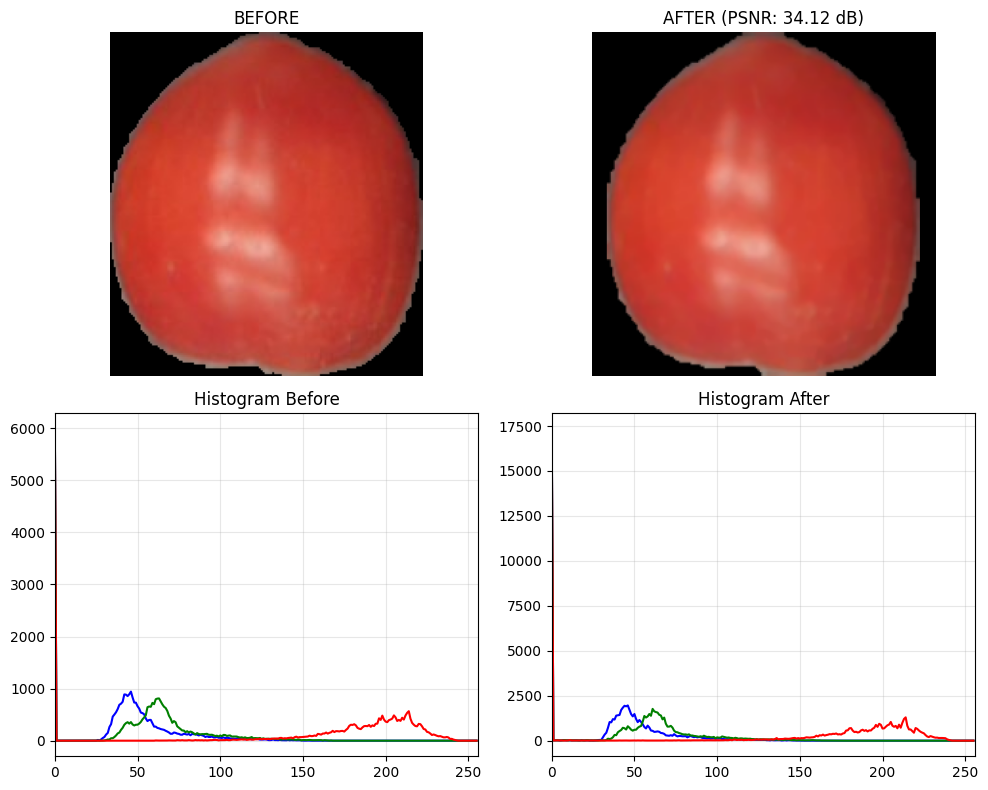

In [ ]:
# ==========================================
# TAHAP 2: IMAGE ENHANCEMENT & PREPROCESSING
# ==========================================

import os
import cv2
import glob
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm

# --- 1. SETUP & KONFIGURASI ---
drive.mount('/content/drive')

# PASTE PATH FOLDER DI SINI
INPUT_PATH = '/content/drive/MyDrive/PCVK/datasetPBL/output-segmentation'
OUTPUT_PATH = '/content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced'

print(f"📂 Input: {INPUT_PATH}")
print(f"📂 Output: {OUTPUT_PATH}")

if not os.path.exists(INPUT_PATH):
    print("❌ Path Input tidak ditemukan! Cek kembali path Google Drive.")
else:
    print("✅ Path siap.")

# --- 2. FUNGSI UTAMA: PREPROCESSING ---
def preprocess_image(img):
    if img is None: return None

    # A. Denoising (Median Blur)
    denoised = cv2.medianBlur(img, 3)

    # B. Morphological Closing (Menutup lubang kecil)
    kernel = np.ones((3,3), np.uint8)
    closing = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)

    # C. Smart Resize (Padding) - Agar gambar tidak gepeng
    old_h, old_w = closing.shape[:2]
    target_size = 256

    # Hitung rasio
    ratio = min(target_size / old_h, target_size / old_w)
    new_h, new_w = int(old_h * ratio), int(old_w * ratio)

    # Resize proporsional
    resized = cv2.resize(closing, (new_w, new_h))

    # Tempel ke kanvas hitam 256x256
    final_img = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    final_img[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return final_img

# --- 3. EKSEKUSI BATCH (SEMUA FOLDER) ---
def process_dataset(input_root, output_root):
    categories = ['ripe', 'half-ripe', 'unripe']
    total_success = 0

    for category in categories:
        path_in = os.path.join(input_root, category, 'seg')
        path_out = os.path.join(output_root, category)

        if not os.path.exists(path_in):
            print(f"⚠️ Folder tidak ditemukan: {path_in}")
            continue

        if not os.path.exists(path_out):
            os.makedirs(path_out)

        files = glob.glob(os.path.join(path_in, "*.png"))
        print(f"\n🚀 Processing: {category.upper()} ({len(files)} files)")

        for file_path in tqdm(files):
            try:
                img = cv2.imread(file_path)
                processed_img = preprocess_image(img)

                if processed_img is not None:
                    filename = os.path.basename(file_path)
                    cv2.imwrite(os.path.join(path_out, filename), processed_img)
                    total_success += 1
            except Exception as e:
                print(f"Error: {e}")

    print(f"\n✅ Selesai! Total {total_success} gambar tersimpan di: {output_root}")

# Jalankan Proses
process_dataset(INPUT_PATH, OUTPUT_PATH)

# --- 4. ANALISIS PSNR & HISTOGRAM (UNTUK LAPORAN) ---
def calculate_psnr(img1, img2):
    # Resize img1 agar dimensi sama untuk perhitungan
    if img1.shape != img2.shape:
        img1 = cv2.resize(img1, (img2.shape[1], img2.shape[0]))

    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return 100
    return 20 * math.log10(255.0 / math.sqrt(mse))

def plot_histogram(img, title, ax):
    colors = ('b', 'g', 'r')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        ax.plot(hist, color=color)
    ax.set_title(title)
    ax.set_xlim([0, 256])
    ax.grid(True, alpha=0.3)

def analyze_enhancement(input_path, output_path):
    img_before = cv2.imread(input_path)
    img_after = cv2.imread(output_path)

    if img_before is None or img_after is None:
        print("❌ File untuk analisis tidak ditemukan.")
        return

    score_psnr = calculate_psnr(img_before, img_after)
    print(f"\n📊 NILAI PSNR: {score_psnr:.2f} dB")

    # Visualisasi
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    axs[0, 0].imshow(cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB))
    axs[0, 0].set_title("BEFORE")
    axs[0, 0].axis('off')

    axs[0, 1].imshow(cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB))
    axs[0, 1].set_title(f"AFTER (PSNR: {score_psnr:.2f} dB)")
    axs[0, 1].axis('off')

    plot_histogram(img_before, "Histogram Before", axs[1, 0])
    plot_histogram(img_after, "Histogram After", axs[1, 1])

    plt.tight_layout()
    plt.show()

# --- CONTOH PENGGUNAAN ANALISIS ---
# Pastikan nama file di bawah ini ADA di dalam folder
sample_in = os.path.join(INPUT_PATH, 'ripe/seg/ripe (1)_seg.png')
sample_out = os.path.join(OUTPUT_PATH, 'ripe/ripe (1)_seg.png')

analyze_enhancement(sample_in, sample_out)

# **Ekstraksi Fitur**

## **Penjelasan**

### **Kelompok Fitur yang Digunakan:**

### **1. Circular Hue Features (3 Fitur)**

Dipakai untuk merepresentasikan warna dasar tomat (Hue) dalam bentuk matematis yang benar.
Kenapa circular?

Karena Hue bukan angka biasa: 0° (merah) sangat dekat dengan 360° (merah lagi), bukan jauh.

Jadi jika kita tidak perlakukan Hue sebagai “data melingkar”, analisis warna akan salah total.

#### **• mean_cos_H**

Mengubah Hue (warna) menjadi koordinat **sumbu X** pada lingkaran warna.

Interpretasi:

* Nilai mendekati **+1** → warna dominan merah → tomat matang (ripe).
* Nilai mendekati **–1** → warna dominan kehijauan → tomat mentah (unripe).

Ini adalah **pembeda matang vs mentah paling kuat**.

#### **• mean_sin_H**

Komponen **sumbu Y** pada lingkaran warna.

Kenapa perlu?
Agar lokasi warna tomat lebih presisi.
Kalau mean_cos_H mengukur “merah vs hijau”, mean_sin_H mengukur “kuning vs biru”.

Fungsinya:

* Membedakan **kuning/oranye** (half-ripe) dari merah/hijau.

#### **• circ_std_H**

Circular standard deviation = *keragaman warna*.

Interpretasi:

* **Nilai rendah** → warna kulit tomat seragam (merah penuh atau hijau penuh).
* **Nilai tinggi** → warna bercampur (merah + hijau + kuning bersamaan).

Ini cocok untuk mendeteksi **tomat half-ripe**, karena tingkat kematangannya memang tidak seragam.

---

### **2. Fitur Saturation (HSV – Komponen S: 1 Fitur)**

Warna tomat bisa merah pekat, merah kusam, atau hijau cerah, dan semua itu tercermin lewat Saturation.

#### **• mean_S**

Mengukur seberapa “kuat” warna tomat.

Interpretasi:

* **Unripe (hijau)**: warna sangat solid → saturasi tinggi.
* **Half-ripe**: warna mulai bercampur → saturasi sedang.
* **Ripe**: kadang warnanya terlihat lebih lembut/matte karena banyak highlight cahaya → saturasi sedikit menurun.

Fitur ini membantu membedakan **solid green → yellow → red progression**.

---

### **3. LAB Color Feature (Persepsi warna ala manusia, 1 Fitur)**

Ruang warna LAB dirancang agar perubahannya mendekati cara manusia melihat warna.

#### **• mean_a**

Komponen **a*** menyatakan pergeseran warna:

* Nilai negatif = hijau
* Nilai positif = merah

Keunggulan besar mean_a:

* **Stabil terhadap perubahan pencahayaan** (tidak seperti RGB)
* Konsisten menunjukkan tingkat kemerahan tomat

Interpretasi:

* **Unripe** → nilai a* rendah / negatif
* **Half-ripe** → mulai naik
* **Ripe** → a* tinggi

Fitur ini sering menjadi **fitur paling kuat** untuk menentukan kematangan.

---

### **4. RGB Color Indices (Bukan Raw RGB: 4 Fitur)**

Kenapa tidak pakai RGB mentah?

Karena RGB sangat sensitif terhadap:

* gelap-terang ruangan
* shadow
* highlight
* kamera

Jadi kita pakai bentuk *rasio*, bukan nilai mentah.

#### **• norm_R**

R / (R + G + B) → persentase merah terhadap seluruh warna.

Kelebihannya:

* Hilangkan efek gelap—tomat merah di tempat gelap tetap terlihat “merah dominan” (rasio tetap tinggi).
* Pembeda matang vs mentah yang sangat stabil.

#### **• rg_ratio**

(R – G) / (R + G)

Ini indikator paling langsung “merah vs hijau”.

Interpretasi:

* Nilai negatif → kehijauan → unripe
* Nol → seimbang → half-ripe (kuning/oranye)
* Nilai positif → kemerahan kuat → ripe

#### **• mean_R**

Rata-rata nilai kanal merah.
Menggambarkan kemunculan **likopen** (pigmen merah saat pematangan).

* Ripe → tinggi
* Half-ripe → sedang
* Unripe → rendah

#### **• mean_G**

Rata-rata kanal hijau.
Menggambarkan **sisa klorofil**.

* Unripe → tinggi
* Half-ripe → menurun
* Ripe → rendah

Mean_R dan mean_G ini bukan fitur utama, tapi tetap berguna untuk mendukung pola dasar perubahan warna.

---

## **Kesimpulan:**

Karena masing-masing kelompok fitur menangkap **bagian berbeda dari proses pematangan tomat**:

1. **Circular Hue** → warna dasar dan keragaman warna (ripe vs half-ripe vs unripe).
2. **Saturation** → kekuatan warna, perubahan dari solid green ke matte red.
3. **Lab a*** → indikator merah-hijau yang stabil terhadap pencahayaan.
4. **RGB Indices** → rasio warna yang tahan terhadap efek cahaya.

Fitur-fitur ini dipilih agar:

* tidak bias cahaya
* tidak bias shadow
* bisa membedakan 3 kelas
* stabil dan mudah divisualisasikan
* relevan secara fisiologi warna tomat


## **KODE: KUIS 2**

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

In [ ]:
!pip install mahotas
!pip install ace_tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 106.5 MB/s eta 0:00:00


In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# FUNGSI UTAMA EKSTRAKSI FITUR
# ------------------------------------------

def extract_features(img_bgr):
    # Untuk jaga-jaga agar gambar asli tidak termodifikasi maka kita copy
    img_crop = img_bgr.copy()

    # =====================================
    # 1. MASK sederhana yaitu jika semua pixel dianggap valid kecuali pixel yang benar-benar hitam (0,0,0)
    #    gambar: [height[0], width[1], channel rgb[2]]
    #    axis=2 berarti melakukan pengecekan pada bagian channel RGB dari setiap pixel
    #    np.any digunakan untuk mengecek apakah di antara R, G, atau B ada nilai yang bukan 0.
    #    Jika minimal satu channel ada selain 0, maka pixel dianggap bagian tomat (True),
    #    jika semua 0 maka dianggap background hitam (False).
    # =====================================
    mask_bin = np.any(img_crop != 0, axis=2)  # mask_bin nanti dipakai untuk mengabaikan pixel background
    # Nanti menghasilkan R, G, dan B seperti [True, False, True]

    # =====================================
    # 2. Konversi warna ke berbagai ruang warna berdasarkan kelompok fitur tadi
    #    Karena kita butuh 3 ruang warna yang berbeda maka dibutuhkan 3 variabel
    #    Tiap variabel terisi oleh gambar asli yang telah diubah menjadi hsv, rgb, dan lab
    # =====================================
    hsv_crop = cv2.cvtColor(img_crop, cv2.COLOR_BGR2HSV)
    img_rgb  = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB) # Gambar asli itu BGR
    img_lab  = cv2.cvtColor(img_crop, cv2.COLOR_BGR2LAB)

    # =====================================
    # 3. Ekstraksi channel
    #    Ambil setiap channel warna (R, G, B, Hue, Saturation, a*) dengan indexing [:,:,i]
    #    dan ubah ke tipe float agar mudah dihitung nantinya
    #    (karena gambar cv2 bertipe uint8 yang terbatas dan operasi seperti mean() butuh float untuk mendukung pecahan)
    # =====================================
    # RGB (OpenCV dan asli: 0-255)
    R = img_rgb[:,:,0].astype(np.float32) # ambil seluruh pixel channel merah saja
    G = img_rgb[:,:,1].astype(np.float32) # ambil seluruh pixel  hijau saja
    B = img_rgb[:,:,2].astype(np.float32) # ambil seluruh pixel biru saja

    # HSV
    # Hue: (OpenCV: 0-180, Asli: 0-360)
    H_deg = hsv_crop[:,:,0].astype(np.float32) * 2.0  # Hue di OpenCV 0..180 sehingga diubah ke 0..360
    # Saturation: (OpenCV: 0-255, Asli: 0-1)
    S = hsv_crop[:,:,1].astype(np.float32) / 255.0    # Normalisasi Saturation ke 0..1

    # LAB a* (OpenCV: 0–255, Asli: -128 sampai 128)
    a = img_lab[:,:,1].astype(np.float32) - 128.0     # a* di OpenCV 0..255 sehingg diubah ke -128..128

    # Perlu dinormalisasi H, S, a* perlu di normalisasi agar menyimpan nilai dengan skala aslinya

    # =====================================
    # 4. Ambil hanya piksel tomat
    #    Variable ekstraksi sebelumnya akan di filter lagi sesuai dengan mask_bin
    #    sehingga hanya mengambil nilai yang true saja
    #    semisal [true, false, true] maka didapatkan 2 nilai saja [i, i].
    #    mask_bin tadi bernilai True pada area tomat dan False pada background hitam.
    # =====================================
    Rm = R[mask_bin]
    Gm = G[mask_bin]
    Bm = B[mask_bin]
    Hm = H_deg[mask_bin]    # [5°, 10°, 350°, 355°]
    Sm = S[mask_bin]
    am = a[mask_bin]

    # =====================================
    # 5. Circular Hue Feature (Hue sebagai data melingkar)
    #    Hue adalah sudut warna 0–360°. Karena sifatnya melingkar,
    #    perhitungan Hue tidak bisa dilakukan dengan mean biasa dan
    #    diperlukan pengubahan menjadi cos serta sin juga untuk melakukan perhitungan circular.
    # =====================================
    # Ubah Hue (Hm) dari derajat ke radian dahulu agar melingkar
    Hm_rad = np.deg2rad(Hm)

    # Representasi Hue pada koordinat kartesian:
    # Data Hue bersifat melingkar, sehingga tidak bisa dirata-ratakan secara langsung.
    # cos(H) digunakan sebagai komponen X (arah merah ↔ cyan),
    mean_cos_H = float(np.cos(Hm_rad).mean()) if Hm.size else 0
    # sin(H) digunakan sebagai komponen Y (arah kuning/hijau ↔ biru/magenta).
    mean_sin_H = float(np.sin(Hm_rad).mean()) if Hm.size else 0
    # Rataan komponen ini digunakan untuk menggambarkan arah warna dominan nantinya
    # Sehingga jika nilai mean_cos_H dan mean_sin_H tinggi artinya tomat mengarah ke unripe atau ripe karena nilai dalam radian konsisten
    # Namun jika nilainya rendah maka tomat itu lebih ke half-ripe karena dalam radian memiliki beragam nilai yang membuat rata-rata menjadi tidak konsisten

    # Hitung panjang vektor resultant dari hasil mean cos dan sin tadi
    # Jika Hue konsisten (warna seragam), panjang vektor mendekati 1.
    # Jika Hue bercampur (warna bervariasi), panjang vektor mendekati 0.
    R_length = np.sqrt(mean_cos_H**2 + mean_sin_H**2)

    # Circular standard deviation (circular variance):
    # Semakin besar circ_std_H → warna semakin tidak seragam (ciri half-ripe).
    # Semakin kecil → warna semakin seragam (ripe atau unripe).
    circ_std_H = 1.0 - R_length


    # =========================================================
    # 6. Mean Saturation (HSV)
    #    Saturation menunjukkan tingkat kepekatan warna.
    #    Semakin tinggi nilai mean_S → warna tomat semakin pekat (ciri tomat matang).
    # =========================================================
    mean_S = float(Sm.mean()) if Sm.size else 0

    # =========================================================
    # 7. Mean a* (LAB)
    #    Channel a* stabil terhadap cahaya:
    #    Nilai negatif → hijau, nilai positif → merah.
    #    Rataan a* sangat efektif untuk membedakan unripe vs ripe.
    # =========================================================
    mean_a = float(am.mean()) if am.size else 0

    # =========================================================
    # 8. Normalized RGB Indices
    # =========================================================
    eps = 1e-6   # mencegah pembagian oleh nol

    # Dominansi warna merah relatif terhadap total intensitas RGB.
    norm_R = float((Rm / (Rm + Gm + Bm + eps)).mean()) if Rm.size else 0

    # Rasio merah terhadap hijau (fitur terkuat membedakan ripe vs unripe).
    rg_ratio = float(((Rm - Gm) / (Rm + Gm + eps)).mean()) if Rm.size else 0

    # Rataan nilai merah dan hijau sebagai indikator tambahan fase kematangan.
    mean_R = float(Rm.mean()) if Rm.size else 0
    mean_G = float(Gm.mean()) if Gm.size else 0

    # =====================================
    # 7. Return fitur
    # =====================================
    return {
        # KELOMPOK 1: CIRCULAR HUE
        "mean_cos_H": mean_cos_H,   # Posisi X (Merah vs Cyan)
        "mean_sin_H": mean_sin_H,   # Posisi Y (Hijau vs Magenta)
        "circ_std_H": circ_std_H,   # Tingkat belang/campuran warna (half-ripe detector)

        # KELOMPOK 2: SATURATION
        "mean_S": mean_S,           # Kepekatan warna

        # KELOMPOK 3: LAB
        "mean_a": mean_a,           # Hijau => Merah (stabil cahaya)

        "norm_R": norm_R,           # Dominansi Merah
        "rg_ratio": rg_ratio,       # Merah lawan Hijau

        # KELOMPOK 4: RGB INDICES
        "mean_R": mean_R,           # Indikator Likopen (pigmen merah)
        "mean_G": mean_G,           # Indikator Klorofil (pigmen hijau)
    }, img_rgb, hsv_crop, mask_bin


DATASET_ENH = "/content/drive/MyDrive/PCVK/datasetPBL/Dataset_Enhanced"

# ------------------------------------------
# EKSTRAKSI FITUR SELURUH DATASET
# ------------------------------------------
all_results = []
all_images_rgb = {}
all_images_hsv = {}
all_masks = {}

for tomato in ["ripe","half-ripe","unripe"]:
    folder = f"{DATASET_ENH}/{tomato}"
    imgs = sorted(glob.glob(f"{folder}/*.png"))

    all_images_rgb[tomato] = []
    all_images_hsv[tomato] = []
    all_masks[tomato] = []

    for p in imgs:
        img = cv2.imread(p)
        feats, img_rgb, img_hsv, mask_bin = extract_features(img)

        feats["filename"] = os.path.basename(p)
        feats["label"] = tomato
        feats["path"] = p

        all_results.append(feats)
        all_images_rgb[tomato].append(img_rgb)
        all_images_hsv[tomato].append(img_hsv)
        all_masks[tomato].append(mask_bin)

print("Ekstraksi selesai. Total fitur:", len(all_results))

Ekstraksi selesai. Total fitur: 300


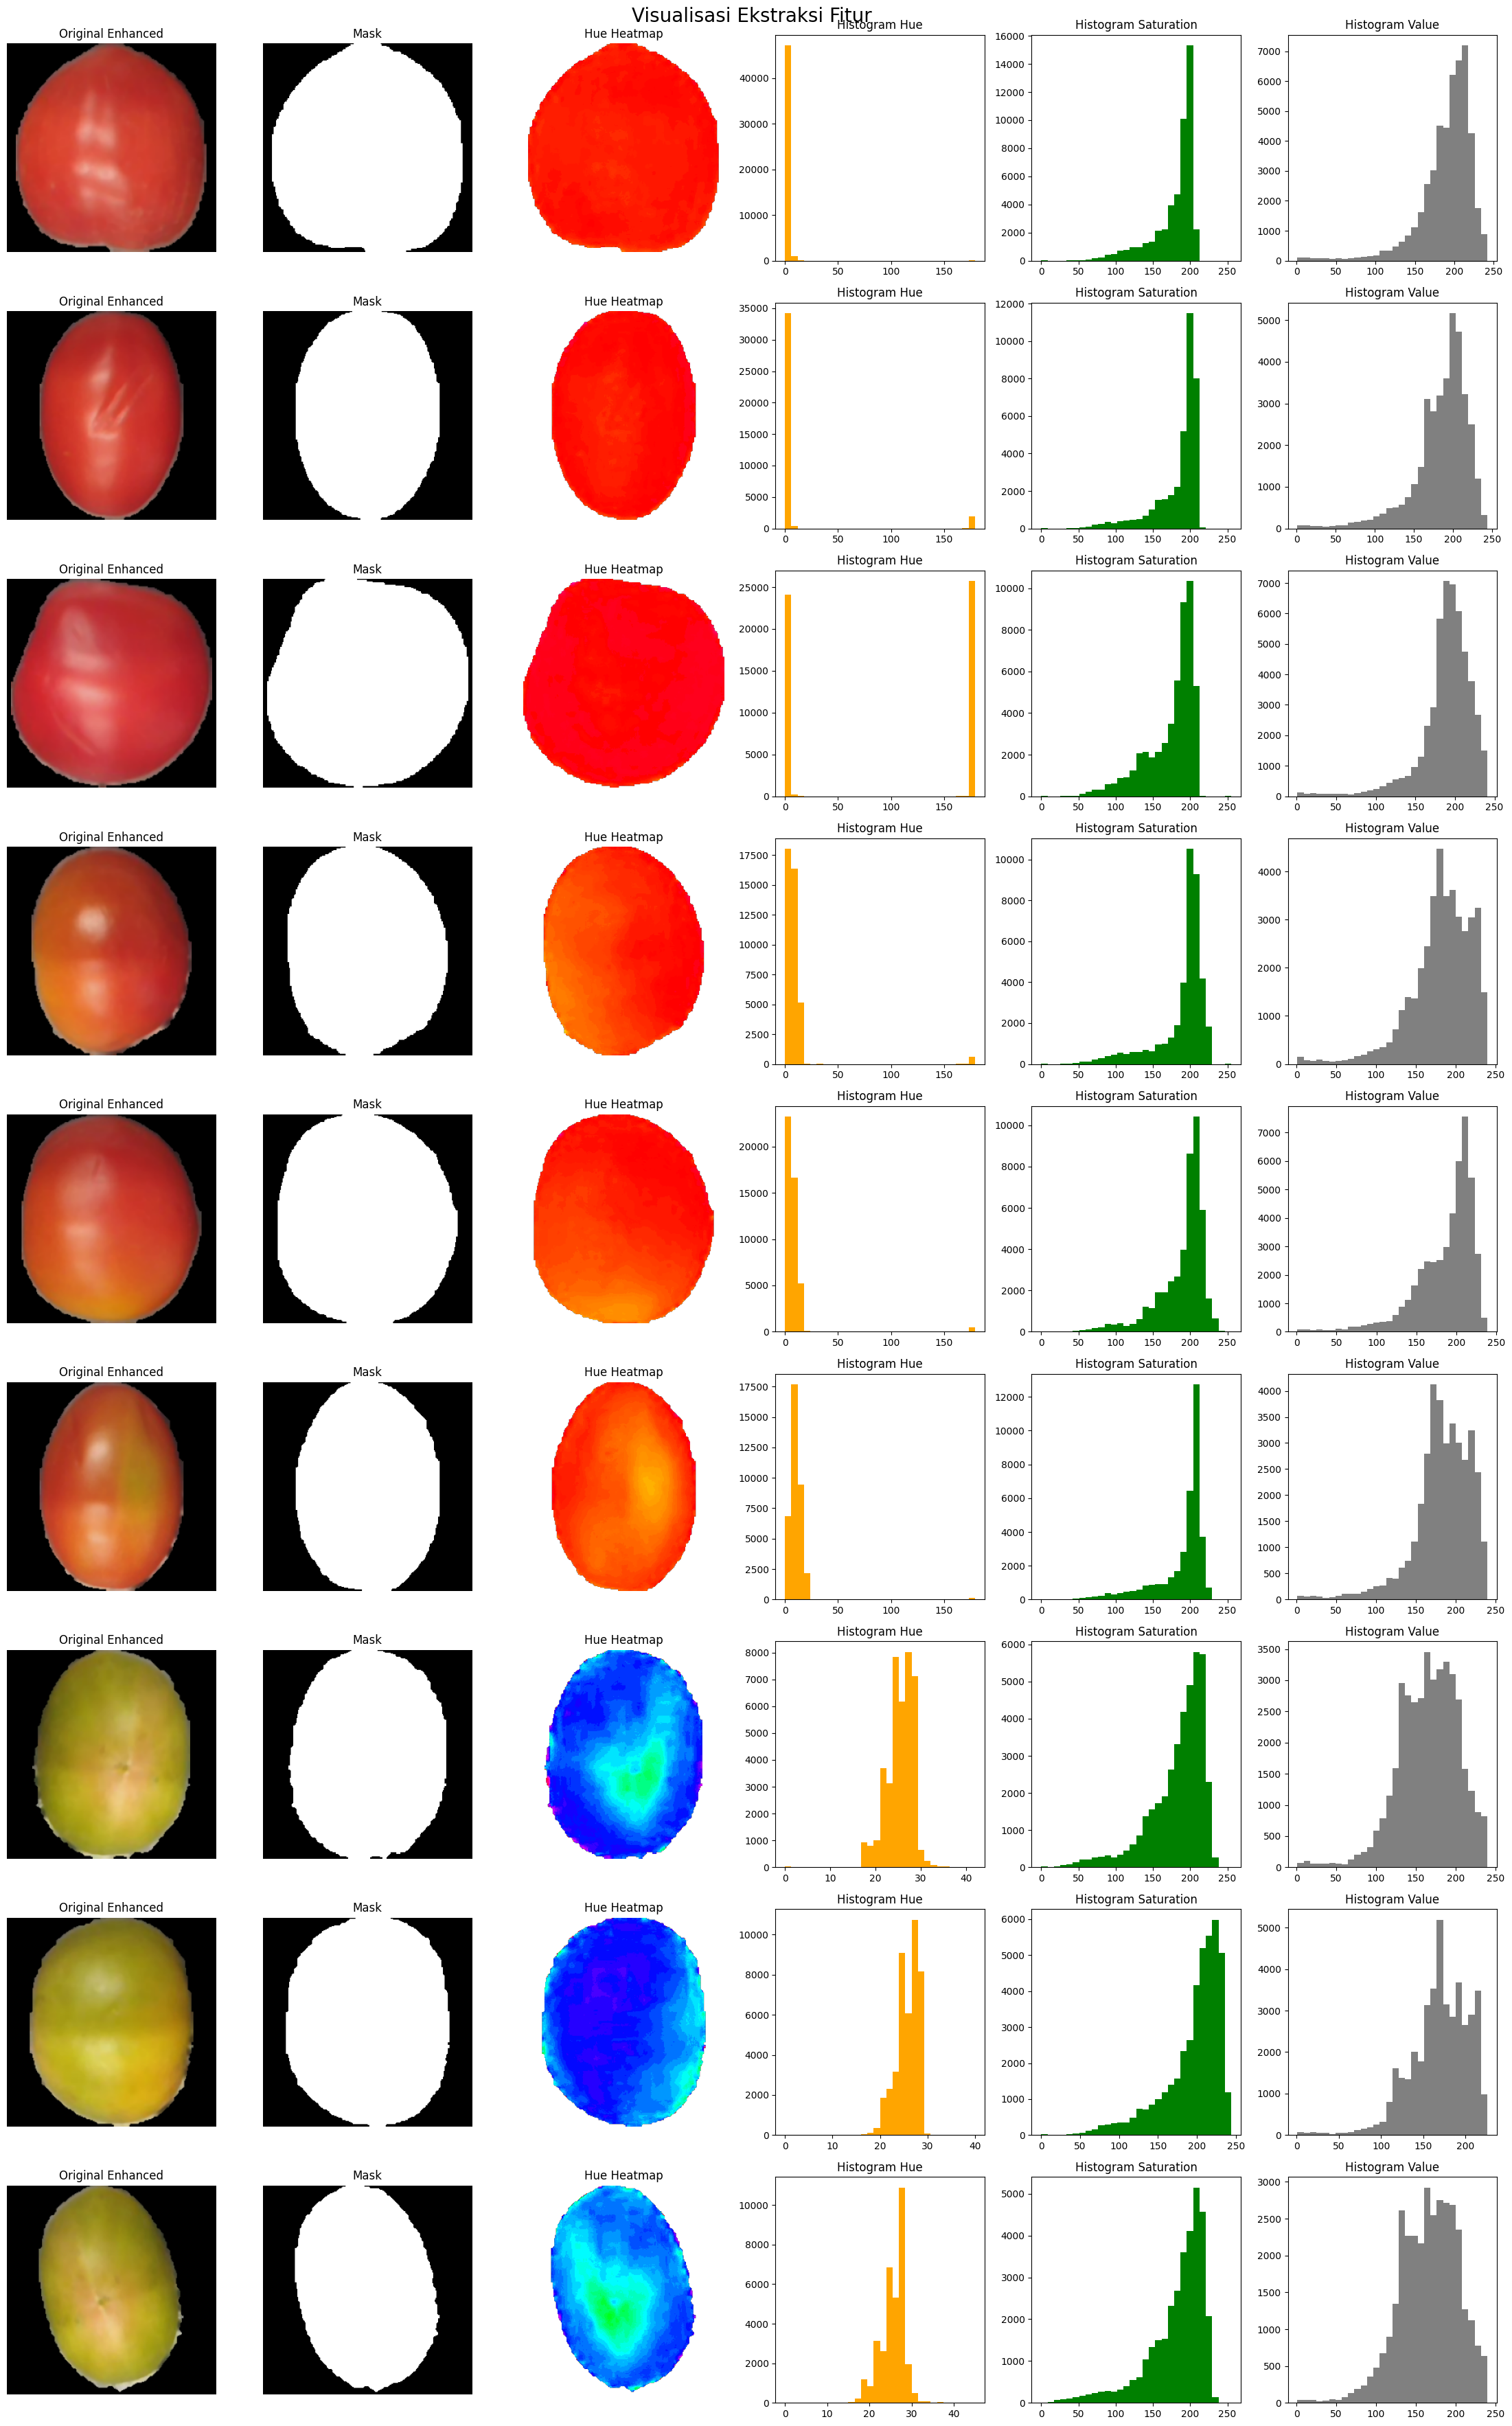


Hue Heatmap (Heatmap ini menunjukkan sebaran warna Hue pada buah. Half-ripe memiliki gradasi warna yang lebih lebar sehingga terlihat area merah bercampur kuning)
=> Warna merah berarti Hue rendah, Warna kuning–hijau berarti Hue lebih tinggi
Histogram Hue (Histogram Hue menunjukkan warna apa saja yang dominan)
=> Half-ripe: histogram dua puncak (campuran kuning–merah), Ripe: histogram terkumpul di Hue rendah, Unripe: histogram terkumpul di Hue tinggi
Histogram Saturation (Histogram Saturation memperlihatkan seberapa kuat warna tomat)
=> Unripe: saturasi tinggi, Half-ripe: saturasi sedang, Ripe: saturasi tidak setinggi unripe (lebih matte)
Histogram Value (Histogram Value menunjukkan tingkat kecerahan warna tomat, untuk membantu memastikan bahwa warna tidak terlalu dipengaruhi bayangan)
=> Tengah: cukup terang atau pas, Kanan: terlalu terang bisa saja menghilangkan detail, Kiri terlalu gelap
Mask (Mask menunjukkan area tomat yang terdeteksi)


In [ ]:
# ------------------------------------------
# VISUALISASI: 3 GAMBAR PERTAMA PER LABEL
# ------------------------------------------

paths_vis = []
for tomato in ["ripe","half-ripe","unripe"]:
    folder = f"{DATASET_ENH}/{tomato}"
    imgs = sorted(glob.glob(f"{folder}/*.png"))
    paths_vis += imgs[:3]

num_images = len(paths_vis)
fig, axes = plt.subplots(num_images, 6, figsize=(22, 4 * num_images))
fig.suptitle("Visualisasi Ekstraksi Fitur\n", fontsize=20)

if num_images == 1:
    axes = axes.reshape(1, 6)

current_row = 0

for tomato in ["ripe","half-ripe","unripe"]:
    for i in range(min(3, len(all_images_rgb[tomato]))):
        img_rgb = all_images_rgb[tomato][i]
        img_hsv = all_images_hsv[tomato][i]
        mask_bin = all_masks[tomato][i]

        ax_row = axes[current_row]

        # --- 1. Original ---
        ax_row[0].imshow(img_rgb)
        ax_row[0].set_title("Original Enhanced")
        ax_row[0].axis("off")

        # --- 2. Mask ---
        ax_row[1].imshow(mask_bin, cmap="gray")
        ax_row[1].set_title("Mask")
        ax_row[1].axis("off")

        # --- 3. Hue Heatmap ---
        Hn = (img_hsv[:,:,0].astype(np.float32)*2)/360.0
        heat = np.full_like(Hn, np.nan)
        heat[mask_bin] = Hn[mask_bin]
        ax_row[2].imshow(heat, cmap="hsv")
        ax_row[2].set_title("Hue Heatmap")
        ax_row[2].axis("off")

        # --- 4. Histogram Hue ---
        ax_row[3].hist(img_hsv[:,:,0][mask_bin], bins=30, color="orange")
        ax_row[3].set_title("Histogram Hue")

        # --- 5. Histogram Saturation ---
        ax_row[4].hist(img_hsv[:,:,1][mask_bin], bins=30, color="green")
        ax_row[4].set_title("Histogram Saturation")

        # --- 6. Histogram Value ---
        ax_row[5].hist(img_hsv[:,:,2][mask_bin], bins=30, color="gray")
        ax_row[5].set_title("Histogram Value")

        current_row += 1

plt.tight_layout()
plt.show()

print('\nHue Heatmap (Heatmap ini menunjukkan sebaran warna Hue pada buah. Half-ripe memiliki gradasi warna yang lebih lebar sehingga terlihat area merah bercampur kuning)')
print('=> Warna merah berarti Hue rendah, Warna kuning–hijau berarti Hue lebih tinggi')
print('Histogram Hue (Histogram Hue menunjukkan warna apa saja yang dominan)')
print('=> Half-ripe: histogram dua puncak (campuran kuning–merah), Ripe: histogram terkumpul di Hue rendah, Unripe: histogram terkumpul di Hue tinggi')
print('Histogram Saturation (Histogram Saturation memperlihatkan seberapa kuat warna tomat)')
print('=> Unripe: saturasi tinggi, Half-ripe: saturasi sedang, Ripe: saturasi tidak setinggi unripe (lebih matte)')
print('Histogram Value (Histogram Value menunjukkan tingkat kecerahan warna tomat, untuk membantu memastikan bahwa warna tidak terlalu dipengaruhi bayangan)')
print('=> Tengah: cukup terang atau pas, Kanan: terlalu terang bisa saja menghilangkan detail, Kiri terlalu gelap')
print('Mask (Mask menunjukkan area tomat yang terdeteksi)')

In [ ]:
# ------------------------------------------
# TABEL FITUR: 40 PERTAMA PER LABEL
# ------------------------------------------
print('Menampilkan contoh fitur 40 per label')

paths_all = []
for tomato in ["ripe","half-ripe","unripe"]:
    folder = f"{DATASET_ENH}/{tomato}"
    imgs = sorted(glob.glob(f"{folder}/*.png"))
    paths_all += imgs[:40]

results_40 = []
for feats in all_results:
    if feats["path"] in paths_all:
        results_40.append(feats)

df = pd.DataFrame(results_40)

if not df.empty:
    ordered_cols = ["filename", "label"] + [c for c in df.columns if c not in ["filename", "label", "path"]]
    df = df[ordered_cols]
    df = df.round(3)

    print("\n=== TABEL FITUR ===")
    print("Semakin terang/kuning, maka data semakin besar\n")
    from IPython.display import display
    display(df.style.background_gradient(cmap="viridis", subset=df.columns[2:]))
else:
    print("Tidak ada fitur yang berhasil diekstraksi.")

Menampilkan contoh fitur 40 per label

=== TABEL FITUR ===
Semakin terang/kuning, maka data semakin besar



,filename,label,mean_cos_H,mean_sin_H,circ_std_H,mean_S,mean_a,norm_R,rg_ratio,mean_R,mean_G
0,ripe (1)_seg.png,ripe,0.994000,0.101000,0.001000,0.701000,47.455000,0.611000,0.475000,189.554000,68.056000
1,ripe (10)_seg.png,ripe,0.996000,0.063000,0.002000,0.722000,49.371000,0.637000,0.526000,184.545000,58.162000
2,ripe (100)_seg.png,ripe,0.999000,-0.013000,0.001000,0.682000,50.506000,0.616000,0.526000,188.443000,59.696000
3,ripe (11)_seg.png,ripe,0.999000,0.006000,0.001000,0.730000,50.568000,0.654000,0.577000,176.491000,47.772000
4,ripe (12)_seg.png,ripe,0.999000,0.015000,0.001000,0.709000,51.942000,0.635000,0.544000,189.482000,56.402000
5,ripe (13)_seg.png,ripe,0.999000,0.021000,0.001000,0.712000,49.583000,0.637000,0.545000,180.154000,54.220000
6,ripe (14)_seg.png,ripe,0.998000,-0.014000,0.002000,0.685000,51.642000,0.616000,0.528000,193.145000,60.357000
7,ripe (15)_seg.png,ripe,0.998000,-0.007000,0.002000,0.688000,50.946000,0.621000,0.531000,190.960000,60.100000
8,ripe (16)_seg.png,ripe,0.997000,0.064000,0.001000,0.713000,48.495000,0.629000,0.515000,182.592000,59.212000
9,ripe (17)_seg.png,ripe,0.998000,0.036000,0.001000,0.715000,50.463000,0.641000,0.544000,185.162000,55.647000


## **Bagian Visualisasi (Opsional untuk presentasi)**


Explained variance PCA:
PC1: 0.7778046345178237
PC2: 0.13985985233319193
PC3: 0.0489030580509736
Total PCA2: 0.9176644868510155
Total PCA3: 0.9665675449019892


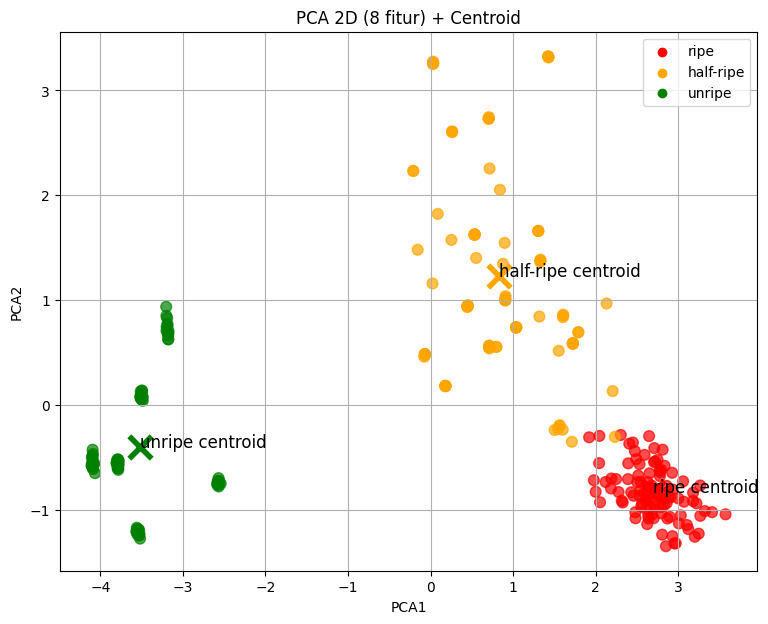

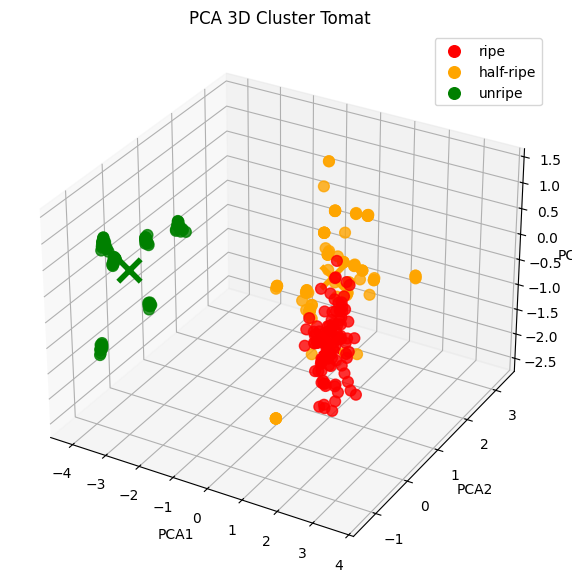

In [ ]:
# =====================   PCA   =========================
df = pd.DataFrame(all_results)

# Ambil hanya fitur numerik untuk PCA
feature_cols = [c for c in df.columns if c not in ["filename", "label", "path"]]
X = df[feature_cols].values

# ==============================================
# STANDARDISASI
# ==============================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===========================================================
# PCA UNTUK SELURUH VISUALISASI
# (SATU PCA → agar konsisten untuk 2D, 3D, biplot, loading)
# ===========================================================
pca = PCA(n_components=3)
Xp = pca.fit_transform(X_scaled)

# Simpan nilai PCA ke DataFrame
df["PCA1"] = Xp[:,0]
df["PCA2"] = Xp[:,1]
df["PCA3"] = Xp[:,2]

# Variansi yang dijelaskan → menunjukkan seberapa besar informasi yang ditangkap PCA
expl2 = pca.explained_variance_ratio_[0:2].sum()
expl3 = pca.explained_variance_ratio_[0:3].sum()

print("\nExplained variance PCA:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("PC3:", pca.explained_variance_ratio_[2])
print("Total PCA2:", expl2)
print("Total PCA3:", expl3)


# ===========================================================
#               VISUALISASI PCA 2D (PC1 vs PC2)
# ===========================================================
# Warna berdasarkan kelas tomat
color_map = {
    "ripe": "red",
    "half-ripe": "orange",
    "unripe": "green"
}
df["color"] = df["label"].map(color_map)

plt.figure(figsize=(9,7))

# Scatter 2D PCA
plt.scatter(df["PCA1"], df["PCA2"], c=df["color"], s=60, alpha=0.7)

# ====================================================
# Tambahkan Centroid (Titik tengah setiap cluster)
# - Memperjelas posisi cluster
# - Membantu memahami pemisahan data
# ====================================================
centers = df.groupby("label")[["PCA1","PCA2"]].mean()

for label, row in centers.iterrows():
    # Titik 'X' menunjukkan centroid
    plt.scatter(row["PCA1"], row["PCA2"],
                c=color_map[label], s=260,
                marker="x", linewidth=4)
    plt.text(row["PCA1"], row["PCA2"],
             f"{label} centroid", fontsize=12)

# Legend manual agar warna tetap muncul
for lab, col in color_map.items():
    plt.scatter([], [], c=col, label=lab)

plt.title("PCA 2D (8 fitur) + Centroid")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.legend()
plt.show()


# ===========================================================
#                   PCA 3D (PC1–PC2–PC3)
# ===========================================================
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter 3D PCA
ax.scatter(df["PCA1"], df["PCA2"], df["PCA3"],
           c=df["color"], s=60, alpha=0.8)

# Centroid untuk 3D (tambah sumbu Z)
for label, row in centers.iterrows():
    z = df[df["label"]==label]["PCA3"].mean()
    ax.scatter(row["PCA1"], row["PCA2"], z,
               c=color_map[label], marker="x", s=260, linewidth=4)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("PCA 3D Cluster Tomat")

# Legend manual
for lab, col in color_map.items():
    ax.scatter([], [], [], c=col, label=lab, s=70)
ax.legend()
plt.show()


=== PCA LOADING MATRIX ===
                PCA1      PCA2      PCA3
mean_cos_H  0.373531  0.091853  0.019175
mean_sin_H -0.376567  0.020213 -0.047529
circ_std_H -0.017756  0.835337 -0.478477
mean_S     -0.237634  0.500324  0.802929
mean_a      0.376941  0.033039  0.077673
norm_R      0.369766  0.106751  0.234175
rg_ratio    0.375740  0.011742  0.109644
mean_R      0.321731  0.173837 -0.170309
mean_G     -0.372000  0.014085 -0.147782



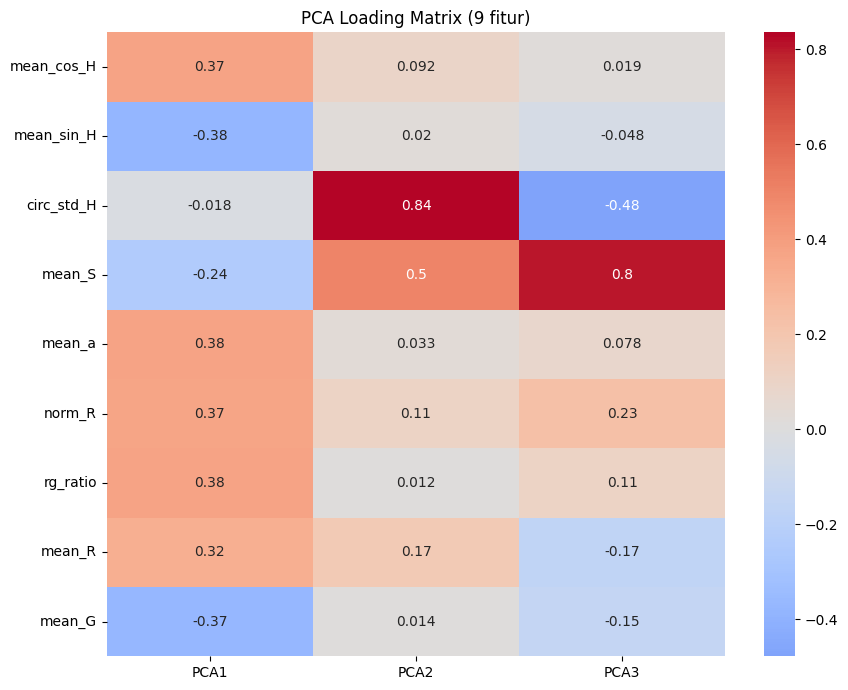

In [ ]:
# ===========================================================
#                 PCA LOADING MATRIX
# ===========================================================
# Loading matrix menunjukkan:
# - kontribusi masing–masing fitur terhadap setiap komponen PCA
# - semakin besar nilai absolut → semakin penting fitur tsb
loading = pd.DataFrame(
    pca.components_.T,
    columns=["PCA1","PCA2","PCA3"],
    index=feature_cols
)

print("\n=== PCA LOADING MATRIX ===")
print(loading)
print()

plt.figure(figsize=(9,7))
sns.heatmap(loading, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loading Matrix (9 fitur)")
plt.tight_layout()
plt.show()


=== RANKING KONTRIBUSI FITUR TERHADAP PC1 ===
mean_a        0.376941
mean_sin_H    0.376567
rg_ratio      0.375740
mean_cos_H    0.373531
mean_G        0.372000
norm_R        0.369766
mean_R        0.321731
mean_S        0.237634
circ_std_H    0.017756
Name: PCA1, dtype: float64


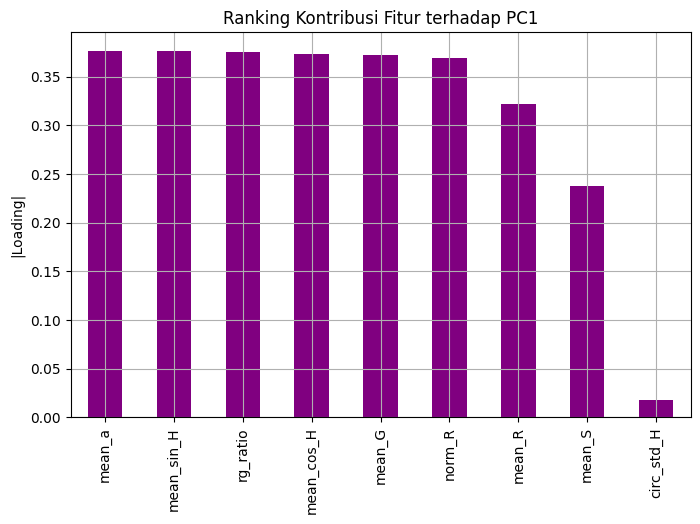

In [ ]:
# ===========================================================
#      RANKING KONTRIBUSI FITUR
# ===========================================================
# Goal:
# Menampilkan fitur mana yang paling berpengaruh terhadap PC1.
# PC1 adalah komponen utama pertama (arah variansi terbesar pada data).
# Loadings PCA menunjukkan seberapa kuat setiap fitur menarik PC1 ke arah tertentu.
# Semakin besar nilai loading (positif atau negatif), semakin besar kontribusinya.
# Oleh karena itu digunakan .abs() (magnitudo) karena tanda + / - hanya arah, bukan kekuatan.

# importance = loading["PCA1"].abs().sort_values(ascending=False)
#   loading["PCA1"] → mengambil kolom PC1 dari loading matrix (nilai kontribusi tiap fitur)
#   .abs()           → mengambil nilai absolut (besar kontribusi, abaikan arah)
#   .sort_values()   → mengurutkan fitur dari kontribusi terbesar ke kecil
importance = loading["PCA1"].abs().sort_values(ascending=False)

print("\n=== RANKING KONTRIBUSI FITUR TERHADAP PC1 ===")
print(importance)

# Plot batang untuk memvisualisasikan fitur mana yang punya kontribusi terbesar.
# Semakin tinggi batang → fitur tersebut paling menjelaskan variansi dataset.
plt.figure(figsize=(8,5))
importance.plot(kind="bar", color="purple")
plt.title("Ranking Kontribusi Fitur terhadap PC1")  # PC1 = variasi terbesar pada seluruh fitur
plt.ylabel("|Loading|")                             # loading = elemen eigenvector PC1
plt.grid(True)
plt.show()

# Manhattan

In [ ]:
# ===============================
# TRAIN-TEST SPLIT
# ===============================

from sklearn.model_selection import train_test_split

# Siapkan data
df = pd.DataFrame(all_results)

# Ambil feature columns
feature_cols = [c for c in df.columns if c not in ["filename", "label", "path"]]
X = df[feature_cols].values
y = df["label"].values

# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Total dataset: {len(X)} gambar")
print(f"Training set: {len(X_train)} gambar ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} gambar ({len(X_test)/len(X)*100:.1f}%)")
print()
print("Distribusi per class pada Training Set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"  {cls}: {count} gambar")
print()
print("Distribusi per class pada Test Set:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    print(f"  {cls}: {count} gambar")
print("=" * 60)

TRAIN-TEST SPLIT
Total dataset: 300 gambar
Training set: 240 gambar (80.0%)
Test set: 60 gambar (20.0%)

Distribusi per class pada Training Set:
  half-ripe: 80 gambar
  ripe: 80 gambar
  unripe: 80 gambar

Distribusi per class pada Test Set:
  half-ripe: 20 gambar
  ripe: 20 gambar
  unripe: 20 gambar


In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ===============================
#  MANHATTAN DISTANCE CLASSIFIER
# ===============================

import numpy as np

# Hitung centroid berdasarkan data training
centroids = {}

for cls in np.unique(y_train):
    centroids[cls] = X_train_scaled[y_train == cls].mean(axis=0)

print("Centroid per kelas telah dihitung.")


Centroid per kelas telah dihitung.


In [ ]:
def predict_manhattan(sample, centroids):
    distances = {cls: np.sum(np.abs(sample - mu)) for cls, mu in centroids.items()}
    return min(distances, key=distances.get)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_manhattan = [predict_manhattan(s, centroids) for s in X_test_scaled]
y_pred_manhattan = np.array(y_pred_manhattan)

acc_manhattan = accuracy_score(y_test, y_pred_manhattan)
cm_manhattan = confusion_matrix(y_test, y_pred_manhattan)

print("Akurasi Manhattan:", acc_manhattan)
print("\nClassification Report:\n", classification_report(y_test, y_pred_manhattan))
print("\nConfusion Matrix:\n", cm_manhattan)


Akurasi Manhattan: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

   half-ripe       1.00      0.90      0.95        20
        ripe       0.91      1.00      0.95        20
      unripe       1.00      1.00      1.00        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60


Confusion Matrix:
 [[18  2  0]
 [ 0 20  0]
 [ 0  0 20]]


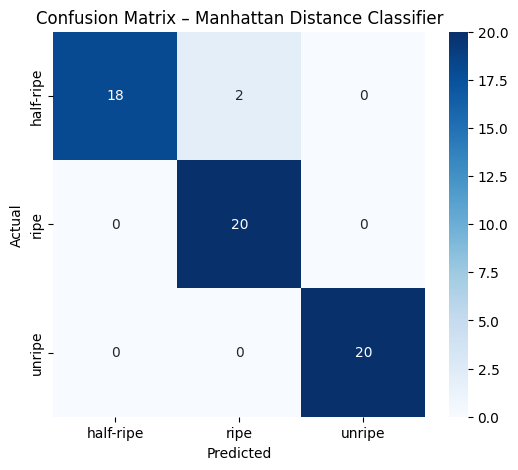

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_manhattan, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title("Confusion Matrix – Manhattan Distance Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



PERHITUNGAN AKURASI MANUAL

TABEL AKURASI PER CLASS:
----------------------------------------------------------------------
    Kelas  Total Gambar  Benar  Salah Akurasi (%)
half-ripe            20     18      2      90.00%
     ripe            20     20      0     100.00%
   unripe            20     20      0     100.00%

TABEL AKURASI KESELURUHAN:
----------------------------------------------------------------------
 Metrik  Total Test  Benar  Salah Akurasi (%)
Akurasi          60     58      2      96.67%



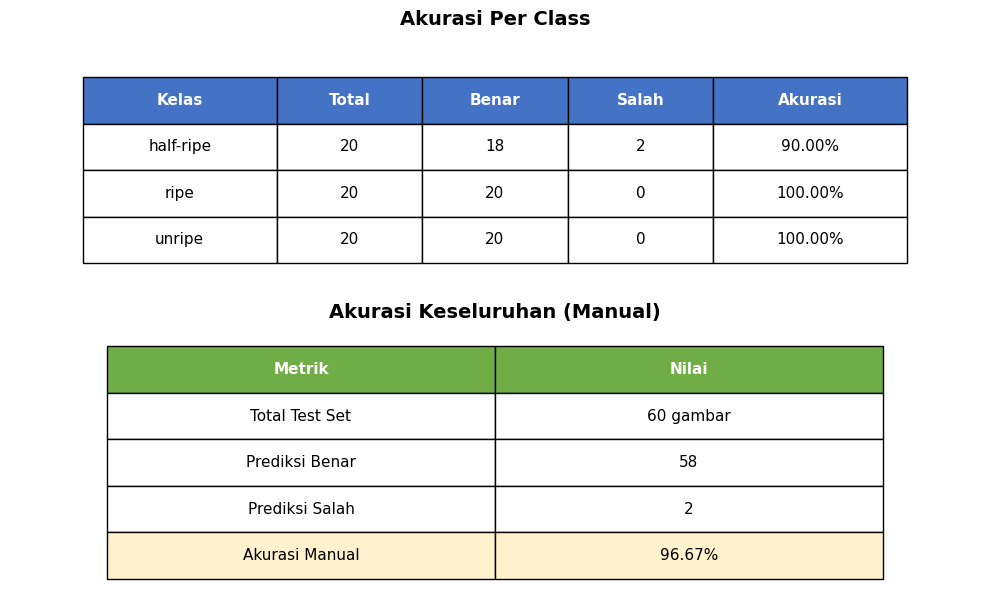


Perhitungan akurasi manual selesai!

VISUALISASI DETAIL PREDIKSI YANG SALAH

Total prediksi salah: 2 dari 60 gambar test
Menampilkan 2 prediksi salah pertama...



/tmp/ipython-input-3688275663.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


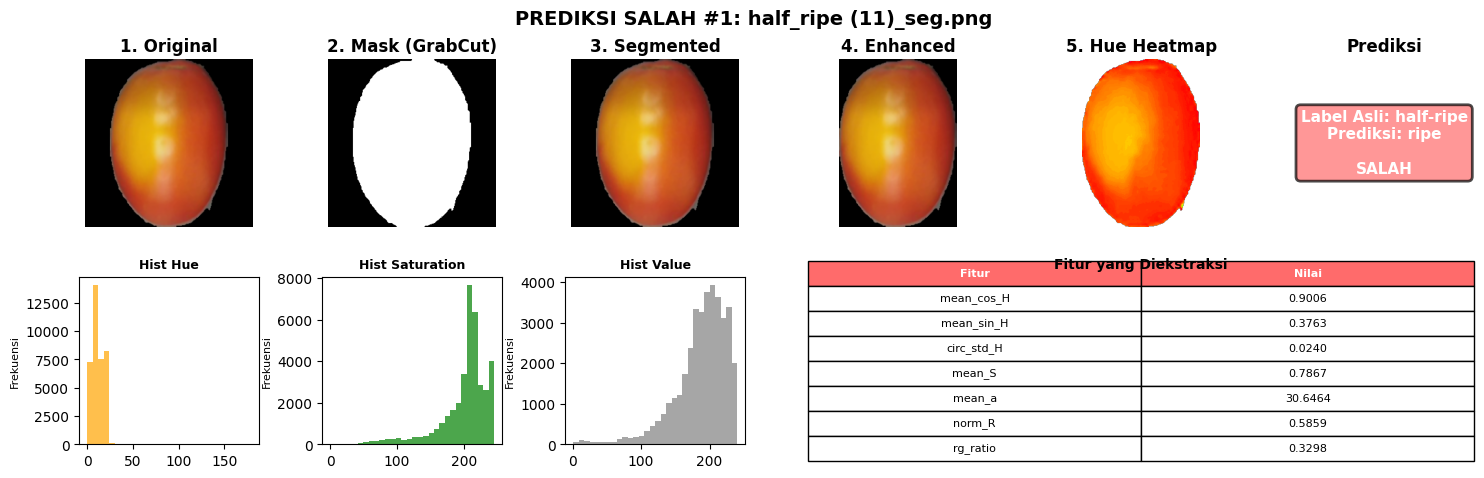

[1] half_ripe (11)_seg.png
    → Label Asli: half-ripe, Prediksi: ripe


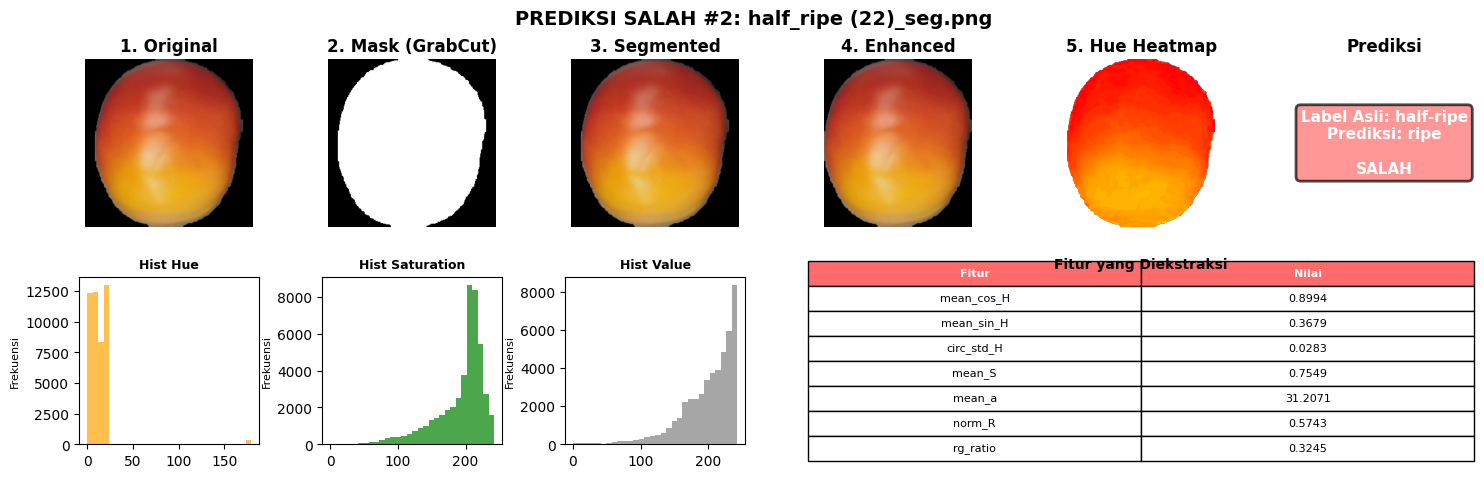

[2] half_ripe (22)_seg.png
    → Label Asli: half-ripe, Prediksi: ripe

Visualisasi prediksi salah selesai!


In [ ]:
# ========================================================================
# PERHITUNGAN AKURASI MANUAL
# ========================================================================
# Akurasi Manual: Hitung langsung berapa prediksi benar vs salah
# Cara: Bandingkan y_test dengan y_pred_manhattan, hitung yang sama

print("\n" + "="*70)
print("PERHITUNGAN AKURASI MANUAL")
print("="*70)

# ========== TABEL VISUAL ==========
print("\nTABEL AKURASI PER CLASS:")
print("-" * 70)

df_accuracy = pd.DataFrame(per_class_data)
print(df_accuracy.to_string(index=False))

print("\nTABEL AKURASI KESELURUHAN:")
print("-" * 70)

df_overall = pd.DataFrame([{
    'Metrik': 'Akurasi',
    'Total Test': total_test,
    'Benar': correct_predictions,
    'Salah': incorrect_predictions,
    'Akurasi (%)': f"{overall_accuracy * 100:.2f}%"
}])
print(df_overall.to_string(index=False))

print("\n" + "="*70)

# ========== VISUALISASI TABEL DENGAN MATPLOTLIB ==========
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Tabel Per-Class
ax1.axis('off')
table1_data = []
table1_data.append(['Kelas', 'Total', 'Benar', 'Salah', 'Akurasi'])
for _, row in df_accuracy.iterrows():
    table1_data.append([
        row['Kelas'],
        str(row['Total Gambar']),
        str(row['Benar']),
        str(row['Salah']),
        row['Akurasi (%)']
    ])

table1 = ax1.table(cellText=table1_data, cellLoc='center', loc='center',
                   colWidths=[0.2, 0.15, 0.15, 0.15, 0.2])
table1.auto_set_font_size(False)
table1.set_fontsize(11)
table1.scale(1, 2.5)

# Header styling
for i in range(5):
    table1[(0, i)].set_facecolor('#4472C4')
    table1[(0, i)].set_text_props(weight='bold', color='white')

ax1.set_title('Akurasi Per Class', fontsize=14, fontweight='bold', pad=20)

# Tabel Overall
ax2.axis('off')
table2_data = [
    ['Metrik', 'Nilai'],
    [f'Total Test Set', f'{total_test} gambar'],
    [f'Prediksi Benar', f'{correct_predictions}'],
    [f'Prediksi Salah', f'{incorrect_predictions}'],
    [f'Akurasi Manual', f'{overall_accuracy * 100:.2f}%']
]

table2 = ax2.table(cellText=table2_data, cellLoc='center', loc='center',
                   colWidths=[0.4, 0.4])
table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1, 2.5)

# Header styling
for i in range(2):
    table2[(0, i)].set_facecolor('#70AD47')
    table2[(0, i)].set_text_props(weight='bold', color='white')

# Highlight akurasi row
table2[(4, 0)].set_facecolor('#FFF2CC')
table2[(4, 1)].set_facecolor('#FFF2CC')

ax2.set_title('Akurasi Keseluruhan (Manual)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nPerhitungan akurasi manual selesai!")

# ========================================================================
# VISUALISASI DETAIL: PREDIKSI YANG SALAH
# ========================================================================

print("\n" + "="*70)
print("VISUALISASI DETAIL PREDIKSI YANG SALAH")
print("="*70)

# Identifikasi prediksi yang salah
wrong_indices = np.where(y_test != y_pred_manhattan)[0]
print(f"\nTotal prediksi salah: {len(wrong_indices)} dari {len(y_test)} gambar test")

if len(wrong_indices) == 0:
    print("Semua prediksi benar! Tidak ada yang salah.")
else:
    print(f"Menampilkan {min(6, len(wrong_indices))} prediksi salah pertama...\n")

    # Ambil maksimal 6 prediksi salah pertama
    for idx_count, wrong_idx in enumerate(wrong_indices[:6]):
        actual_label = y_test[wrong_idx]
        predicted_label = y_pred_manhattan[wrong_idx]

        # Cari gambar yang sesuai dari all_results berdasarkan label
        df_all = pd.DataFrame(all_results)
        samples_with_label = df_all[df_all["label"] == actual_label].reset_index(drop=True)

        # Ambil sample dari test set (hitung index)
        test_indices_for_label = np.where(y_test == actual_label)[0]
        pos_in_label = np.where(test_indices_for_label == wrong_idx)[0][0]

        if pos_in_label < len(samples_with_label):
            sample_data = samples_with_label.iloc[pos_in_label]
            img_path = sample_data["path"]

            # Baca gambar dan proses pipeline
            try:
                # 1. Original
                img_original = cv2.imread(img_path)
                img_rgb_orig = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

                # 2. Segmentasi
                ori, mask, seg, crop = auto_segment_grabcut(img_original)

                if crop is None:
                    continue

                # 3. Enhancement (sudah dilakukan, jadi crop = enhanced)
                img_enhanced = crop
                img_rgb_enh = cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB)

                # 4. Ekstraksi Fitur
                features_dict, img_rgb_feat, img_hsv_feat, mask_bin_feat = extract_features(crop)

                # Tampilkan visualisasi
                fig = plt.figure(figsize=(18, 5))
                gs = GridSpec(2, 6, figure=fig, hspace=0.3, wspace=0.35)

                # --- Row 1: Gambar ---
                # Original
                ax0 = fig.add_subplot(gs[0, 0])
                ax0.imshow(img_rgb_orig)
                ax0.set_title("1. Original", fontweight='bold')
                ax0.axis('off')

                # Mask Segmentasi
                ax1 = fig.add_subplot(gs[0, 1])
                ax1.imshow(mask, cmap='gray')
                ax1.set_title("2. Mask (GrabCut)", fontweight='bold')
                ax1.axis('off')

                # Segmented
                ax2 = fig.add_subplot(gs[0, 2])
                ax2.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
                ax2.set_title("3. Segmented", fontweight='bold')
                ax2.axis('off')

                # Enhanced Crop
                ax3 = fig.add_subplot(gs[0, 3])
                ax3.imshow(img_rgb_enh)
                ax3.set_title("4. Enhanced", fontweight='bold')
                ax3.axis('off')

                # Hue Heatmap
                ax4 = fig.add_subplot(gs[0, 4])
                Hn = (img_hsv_feat[:,:,0].astype(np.float32)*2)/360.0
                heat = np.full_like(Hn, np.nan)
                heat[mask_bin_feat] = Hn[mask_bin_feat]
                ax4.imshow(heat, cmap="hsv")
                ax4.set_title("5. Hue Heatmap", fontweight='bold')
                ax4.axis('off')

                # Hasil Prediksi Status
                ax5 = fig.add_subplot(gs[0, 5])
                ax5.axis('off')
                status_color = '#FF6B6B'  # Merah untuk salah
                status_text = "SALAH"
                result_text = f"Label Asli: {actual_label}\nPrediksi: {predicted_label}\n\n{status_text}"
                ax5.text(0.5, 0.5, result_text, ha='center', va='center', fontsize=11,
                        bbox=dict(boxstyle='round', facecolor=status_color, alpha=0.7, edgecolor='black', linewidth=2),
                        fontweight='bold', color='white')
                ax5.set_title("Prediksi", fontweight='bold')

                # --- Row 2: Fitur & Histogram ---
                # Histogram Hue
                ax6 = fig.add_subplot(gs[1, 0])
                ax6.hist(img_hsv_feat[:,:,0][mask_bin_feat], bins=30, color='orange', alpha=0.7)
                ax6.set_title("Hist Hue", fontweight='bold', fontsize=9)
                ax6.set_ylabel("Frekuensi", fontsize=8)

                # Histogram Saturation
                ax7 = fig.add_subplot(gs[1, 1])
                ax7.hist(img_hsv_feat[:,:,1][mask_bin_feat], bins=30, color='green', alpha=0.7)
                ax7.set_title("Hist Saturation", fontweight='bold', fontsize=9)
                ax7.set_ylabel("Frekuensi", fontsize=8)

                # Histogram Value
                ax8 = fig.add_subplot(gs[1, 2])
                ax8.hist(img_hsv_feat[:,:,2][mask_bin_feat], bins=30, color='gray', alpha=0.7)
                ax8.set_title("Hist Value", fontweight='bold', fontsize=9)
                ax8.set_ylabel("Frekuensi", fontsize=8)

                # Fitur Numerik (Tabel)
                ax9 = fig.add_subplot(gs[1, 3:6])
                ax9.axis('off')

                fitur_display = [
                    ["Fitur", "Nilai"],
                    ["mean_cos_H", f"{features_dict['mean_cos_H']:.4f}"],
                    ["mean_sin_H", f"{features_dict['mean_sin_H']:.4f}"],
                    ["circ_std_H", f"{features_dict['circ_std_H']:.4f}"],
                    ["mean_S", f"{features_dict['mean_S']:.4f}"],
                    ["mean_a", f"{features_dict['mean_a']:.4f}"],
                    ["norm_R", f"{features_dict['norm_R']:.4f}"],
                    ["rg_ratio", f"{features_dict['rg_ratio']:.4f}"],
                ]

                table_feat = ax9.table(cellText=fitur_display, cellLoc='center', loc='center',
                                      colWidths=[0.5, 0.5])
                table_feat.auto_set_font_size(False)
                table_feat.set_fontsize(8)
                table_feat.scale(1, 1.5)

                # Header styling
                for i in range(2):
                    table_feat[(0, i)].set_facecolor('#FF6B6B')
                    table_feat[(0, i)].set_text_props(weight='bold', color='white')

                ax9.set_title("Fitur yang Diekstraksi", fontweight='bold', fontsize=10)

                plt.suptitle(f"PREDIKSI SALAH #{idx_count+1}: {sample_data['filename']}",
                            fontsize=14, fontweight='bold', y=0.98)
                plt.tight_layout()
                plt.show()

                print(f"[{idx_count+1}] {sample_data['filename']}")
                print(f"    → Label Asli: {actual_label}, Prediksi: {predicted_label}")

            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

print("\n" + "="*70)
print("Visualisasi prediksi salah selesai!")
print("="*70)

# Testing dengan Manhattan


Saving unripe (12).jpg to unripe (12).jpg

🎯 Prediksi Kematangan (Manhattan): unripe


/tmp/ipython-input-1725358414.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


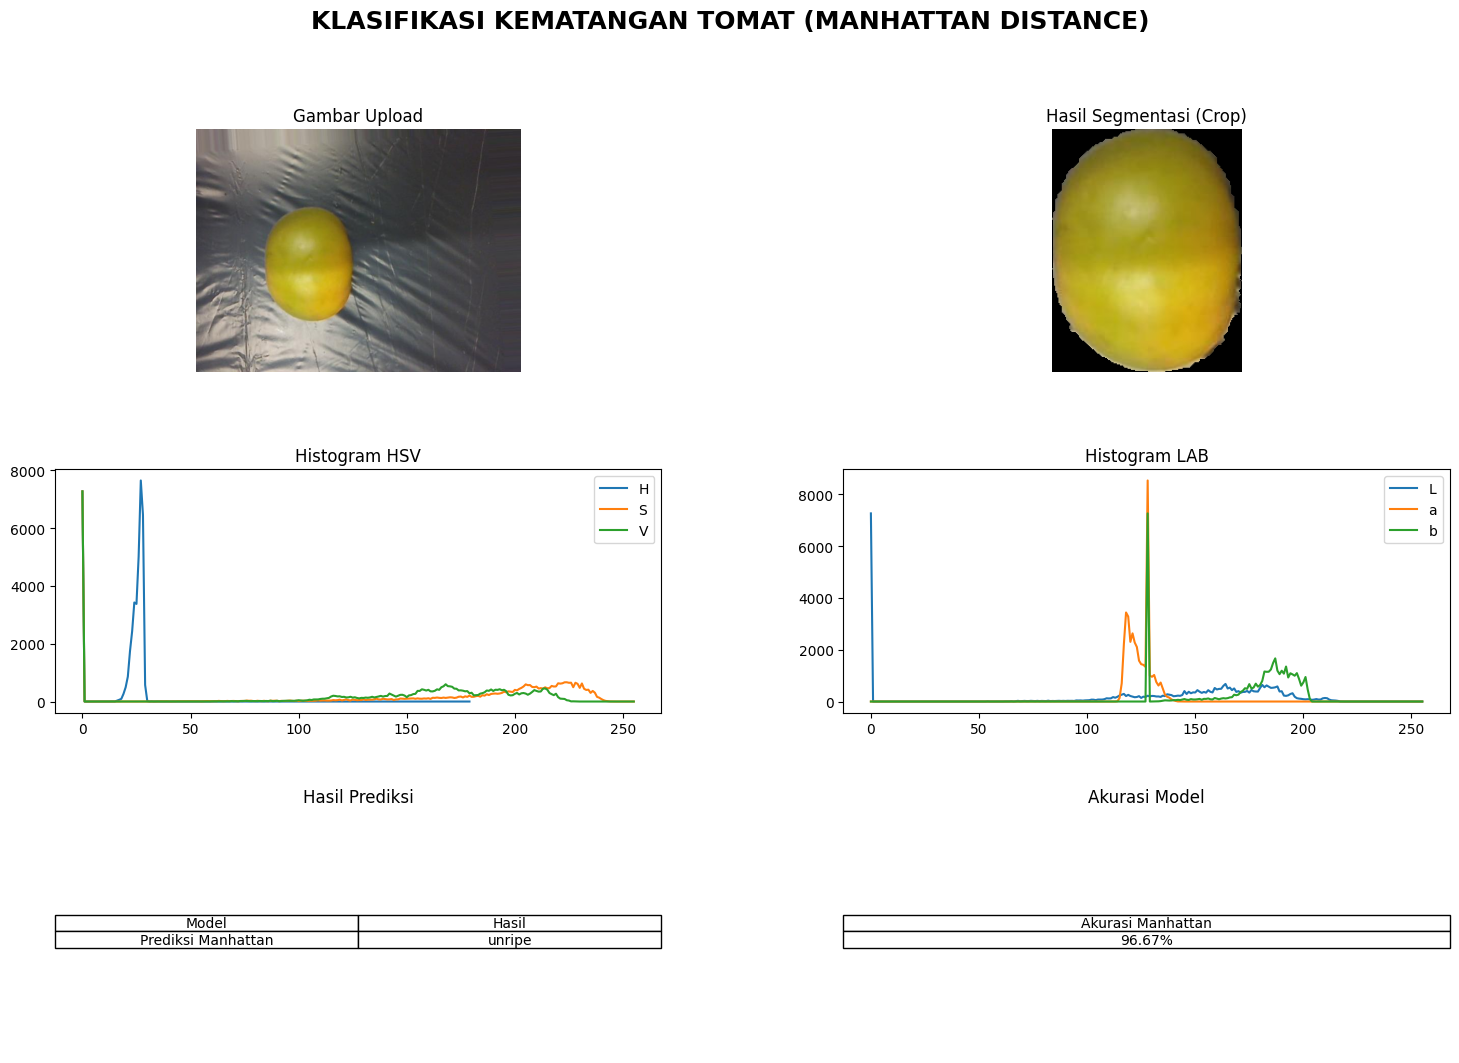

In [ ]:
# Prediksi Tomat Baru - Output Final (Manhattan-Only)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from google.colab import files

# ========================================
# 1. UPLOAD GAMBAR
# ========================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img_bgr = cv2.imread(file_name)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ========================================
# 2. SEGMENTASI
# ========================================
ori, mask, seg, crop = auto_segment_grabcut(img_bgr)

if crop is None:
    raise ValueError("❌ Segmentasi gagal! Tomat tidak terdeteksi.")

# ========================================
# 3. EKSTRAKSI FITUR
# ========================================
features_dict, img_rgb_feat, img_hsv_feat, mask_bin_feat = extract_features(crop)

fitur_array = np.array([[
    features_dict['mean_cos_H'],
    features_dict['mean_sin_H'],
    features_dict['circ_std_H'],
    features_dict['mean_S'],
    features_dict['mean_a'],
    features_dict['norm_R'],
    features_dict['rg_ratio'],
    features_dict['mean_R'],
    features_dict['mean_G']
]])

# ========================================
# 4. PREPROCESSING (SCALING SAJA)
# ========================================
fitur_scaled = scaler.transform(fitur_array)

# ========================================
# 5. Prediksi Manhattan
# ========================================
pred_manhattan = predict_manhattan(fitur_scaled[0], centroids)
print("\n🎯 Prediksi Kematangan (Manhattan):", pred_manhattan)

# ================================================================
# 6. VISUALISASI LENGKAP
# ================================================================
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# --- Gambar asli ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_rgb)
ax1.set_title("Gambar Upload")
ax1.axis("off")

# --- Hasil segmentasi ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
ax2.set_title("Hasil Segmentasi (Crop)")
ax2.axis("off")

# --- Tabel Prediksi Manhattan ---
ax_pred = fig.add_subplot(gs[2, 0])
ax_pred.axis("off")
ax_pred.table(
    cellText=[["Prediksi Manhattan", pred_manhattan]],
    colLabels=["Model", "Hasil"],
    loc="center",
    cellLoc="center"
)
ax_pred.set_title("Hasil Prediksi")

# --- Tabel Akurasi Manhattan ---
ax_acc = fig.add_subplot(gs[2, 1])
ax_acc.axis("off")
ax_acc.table(
    cellText=[[f"{acc_manhattan * 100:.2f}%"]],
    colLabels=["Akurasi Manhattan"],
    loc="center",
    cellLoc="center"
)
ax_acc.set_title("Akurasi Model")

# --- Histogram HSV ---
crop_hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
ax_hist_hsv = fig.add_subplot(gs[1, 0])
ax_hist_hsv.plot(cv2.calcHist([crop_hsv], [0], None, [180], [0, 180]), label="H")
ax_hist_hsv.plot(cv2.calcHist([crop_hsv], [1], None, [256], [0, 256]), label="S")
ax_hist_hsv.plot(cv2.calcHist([crop_hsv], [2], None, [256], [0, 256]), label="V")
ax_hist_hsv.set_title("Histogram HSV")
ax_hist_hsv.legend()

# --- Histogram LAB ---
crop_lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)
ax_hist_lab = fig.add_subplot(gs[1, 1])
ax_hist_lab.plot(cv2.calcHist([crop_lab], [0], None, [256], [0, 256]), label="L")
ax_hist_lab.plot(cv2.calcHist([crop_lab], [1], None, [256], [0, 256]), label="a")
ax_hist_lab.plot(cv2.calcHist([crop_lab], [2], None, [256], [0, 256]), label="b")
ax_hist_lab.set_title("Histogram LAB")
ax_hist_lab.legend()

plt.suptitle("KLASIFIKASI KEMATANGAN TOMAT (MANHATTAN DISTANCE)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()
